In [38]:
import pandas as pd
import numpy as np
import plotly.express as px
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, confusion_matrix, r2_score, mean_squared_error

In [39]:
df = pd.DataFrame(pd.read_csv("house_price_analysis.csv"))
print(df.head(5))
print(df.shape)
print(df.columns)
print(df.info())
print(df.isnull().sum())
df.drop_duplicates(inplace=True)
print(df.describe())

   Area  Bedrooms  Bathrooms  Age  Parking  LocationScore    Price
0   900         2          1   10        1              6  3200000
1  1100         2          2    8        1              7  4200000
2  1400         3          2    6        1              8  5500000
3  1600         3          3    5        2              9  6800000
4  1800         4          3    4        2              9  7600000
(15, 7)
Index(['Area', 'Bedrooms', 'Bathrooms', 'Age', 'Parking', 'LocationScore',
       'Price'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Area           15 non-null     int64
 1   Bedrooms       15 non-null     int64
 2   Bathrooms      15 non-null     int64
 3   Age            15 non-null     int64
 4   Parking        15 non-null     int64
 5   LocationScore  15 non-null     int64
 6   Price          15 non-null     in

<Axes: xlabel='Area', ylabel='Price'>

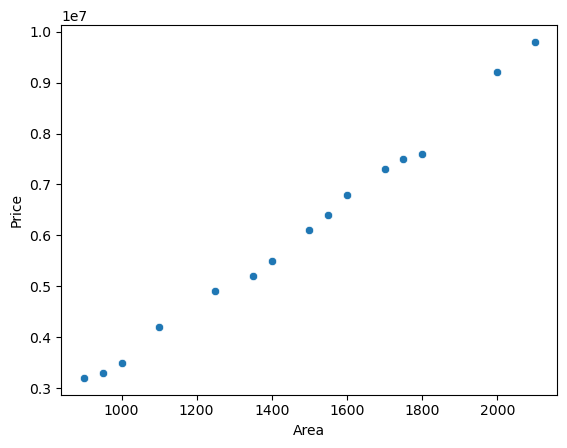

In [40]:
sns.scatterplot(df,x="Area",y="Price")

<Axes: xlabel='Bedrooms', ylabel='Price'>

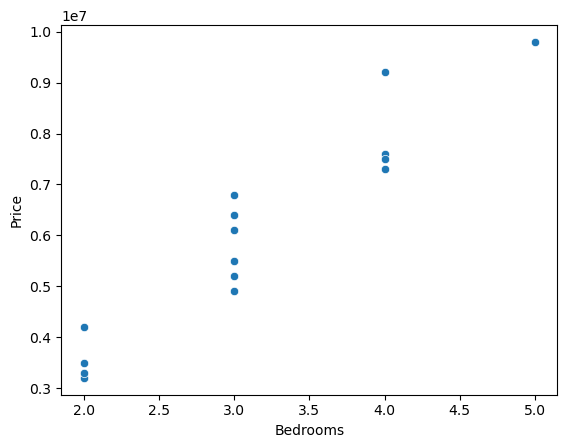

In [41]:
sns.scatterplot(df,x="Bedrooms",y="Price")

<Axes: xlabel='Price'>

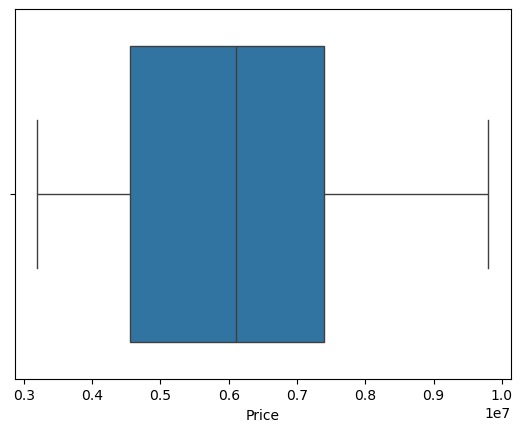

In [42]:
sns.boxplot(df,x="Price")

<Axes: >

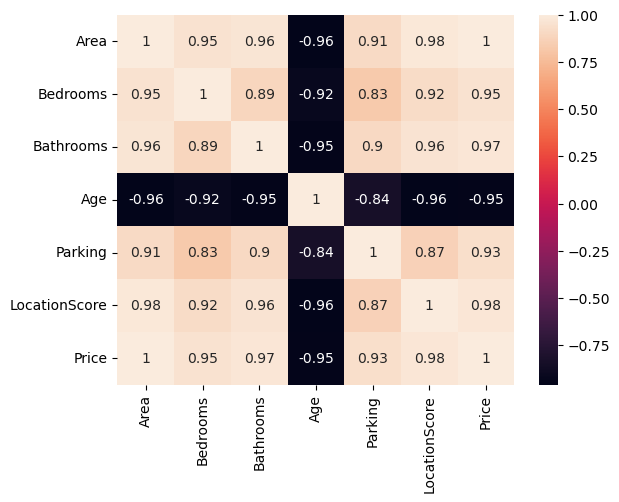

In [43]:
corr = df.corr()
sns.heatmap(corr,annot=True)

<Axes: xlabel='Price', ylabel='Price'>

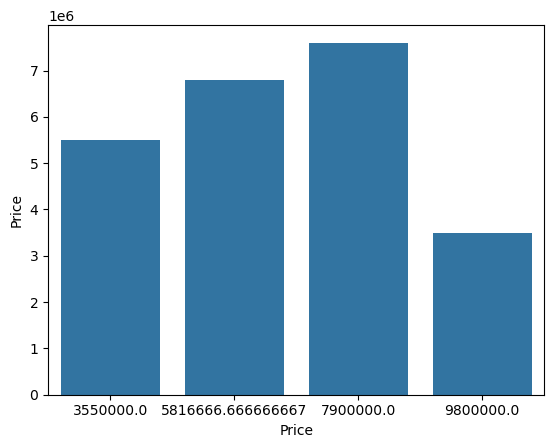

In [44]:
bed = df.groupby("Bedrooms")["Price"].mean()
sns.barplot(df,x=bed,y="Price")

In [45]:
x = df[["Area"]]
y = df["Price"]
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
pre1 = model.predict(x_test)
acc = r2_score(y_test,pre1)
mse = mean_squared_error(y_test,pre1)
print(acc)
print(mse)
dfarr1 = np.array([acc,mse])
print(dfarr1)

0.9906476551249069
58192368111.69043
[9.90647655e-01 5.81923681e+10]


In [46]:
x = df.drop("Price",axis=1)
y = df["Price"]
x = pd.get_dummies(x)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = LinearRegression()
model.fit(x_train,y_train)
pre2 = model.predict(x_test)
acc = r2_score(y_test,pre2)
mse = mean_squared_error(y_test,pre2)
print(acc)
print(mse)
dfarr2 = np.array([acc,mse])
print(dfarr2)

0.9981179806604562
11710342557.161705
[9.98117981e-01 1.17103426e+10]


In [47]:
x = df.drop("Price",axis=1)
y = df["Price"]
x = pd.get_dummies(x)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
poly = PolynomialFeatures(degree=2)
x_train_poly = poly.fit_transform(x_train,x_test)
x_test_poly = poly.transform(x_test)
model = LinearRegression()
model.fit(x_train_poly,y_train)
pre3 = model.predict(x_test_poly)
acc = r2_score(y_test,pre3)
mse = mean_squared_error(y_test,pre3)
print(acc)
print(mse)
dfarr3 = np.array([acc,mse])
print(dfarr3)

0.9918805921244043
50520760114.818115
[9.91880592e-01 5.05207601e+10]


In [48]:
dfReg = pd.DataFrame(np.array([dfarr1,dfarr2,dfarr3]),columns=["R2 Score","MSE"],index=["Simple LR","Multiple LR","Polynomial"])
dfReg

,R2 Score,MSE
Simple LR,0.990648,5.819237e+10
Multiple LR,0.998118,1.171034e+10
Polynomial,0.991881,5.052076e+10


In [49]:
def compare(price):
    if price > df["Price"].median():
        return 1
    else:
        return 0

df["HighPrice"]=df["Price"].apply(compare)
df

,Area,Bedrooms,Bathrooms,Age,Parking,LocationScore,Price,HighPrice
0,900,2,1,10,1,6,3200000,0
1,1100,2,2,8,1,7,4200000,0
2,1400,3,2,6,1,8,5500000,0
3,1600,3,3,5,2,9,6800000,1
4,1800,4,3,4,2,9,7600000,1
5,1000,2,1,12,1,6,3500000,0
6,1250,3,2,7,1,7,4900000,0
7,1500,3,2,5,2,8,6100000,0
8,1700,4,3,3,2,9,7300000,1
9,2000,4,4,2,3,10,9200000,1


In [51]:
x = df.drop("HighPrice",axis=1)
y = df["HighPrice"]
x = pd.get_dummies(x)
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
model = KNeighborsClassifier(n_neighbors=3)
model.fit(x_train,y_train)
pre = model.predict(x_test)
print("Accuracy : ",accuracy_score(y_test,pre))
print("Confusion Matrix : ",confusion_matrix(y_test,pre))
print("F1 Score : ",recall_score(y_test,pre,pos_label=1))
print("Precision Score : ",precision_score(y_test,pre,pos_label=1))
print("Recall Score : ",recall_score(y_test,pre,pos_label=1))
knn = [accuracy_score(y_test,pre),precision_score(y_test,pre,pos_label=1),recall_score(y_test,pre,pos_label=1),recall_score(y_test,pre,pos_label=1)]
arrknn = np.array(knn)
print(arrknn)

Accuracy :  1.0
Confusion Matrix :  [[2 0]
 [0 1]]
F1 Score :  1.0
Precision Score :  1.0
Recall Score :  1.0
[1. 1. 1. 1.]


In [53]:
x = df.drop("HighPrice",axis=1)
y = df["HighPrice"]
x = pd.get_dummies(x)
x_train1, x_test1, y_train1, y_test1 = train_test_split(x,y,test_size=0.2,random_state=42)
model1 = DecisionTreeClassifier(criterion="entropy",max_depth=3,random_state=42)
model1.fit(x_train1,y_train1)
pre1 = model1.predict(x_test1)
print("Accuracy : ",accuracy_score(y_test1,pre1))
print("Confusion Matrix : ",confusion_matrix(y_test1,pre1))
print("F1 Score : ",f1_score(y_test1,pre1,pos_label=1))
print("Precision Score : ",precision_score(y_test1,pre1,pos_label=1))
print("Recall Score : ",recall_score(y_test1,pre1,pos_label=1))
dt = [accuracy_score(y_test1,pre1),precision_score(y_test1,pre1,pos_label=1),recall_score(y_test1,pre1,pos_label=1),recall_score(y_test1,pre1,pos_label=1)]
arrdt = np.array(dt)
print(arrdt)

Accuracy :  1.0
Confusion Matrix :  [[2 0]
 [0 1]]
F1 Score :  1.0
Precision Score :  1.0
Recall Score :  1.0
[1. 1. 1. 1.]


In [55]:
dfarr = np.array([arrknn,arrdt])
dfclass = pd.DataFrame(dfarr,columns=["Accuracy","Precision","Recall","F1 Score"],index=["KNN","Decision Tree"])
dfclass

,Accuracy,Precision,Recall,F1 Score
KNN,1.0,1.0,1.0,1.0
Decision Tree,1.0,1.0,1.0,1.0
